# Reuters C50 - Klasifikacija autora novinskih tekstova
## 01 - Učitavanje i osnovna eksploracija podataka

**Dataset:** Reuters C50 (UCI Machine Learning Repository)  
**Izvor:** https://archive.ics.uci.edu/dataset/217/reuter+50+50  
**Zadatak:** Klasifikacija novinskih članaka prema autoru (50 autora, 50 članaka po autoru)

### Instalacija i uvoz biblioteka

In [1]:
import subprocess, sys
for pkg in ['nltk', 'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'wordcloud']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

> **Zaključak:** Sve neophodne biblioteke su uspešno instalirane. Koriste se: `nltk` za obradu prirodnog jezika, `scikit-learn` za mašinsko učenje, `pandas` i `numpy` za manipulaciju podacima, `matplotlib` i `seaborn` za vizualizaciju, i `wordcloud` za grafički prikaz frekvencija reči.

### Uvoz paketa

In [2]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

DATASET_PATH = '../data'
SLIKE_PATH   = '../slike'
os.makedirs(SLIKE_PATH, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.dpi'] = 120

print('Paketi uspešno uvezeni.')
print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')

Paketi uspešno uvezeni.
NumPy  : 2.5.2
Pandas : 3.0.5


> **Zaključak:** Svi paketi su uspešno uvezeni. Definisane su globalne konstante za putanje do dataseta i foldera za slike, kao i `RANDOM_STATE = 42` koji garantuje reproduktivnost svih eksperimenata.

### Učitavanje dataseta

In [3]:
def load_reuters(base_path):
    records = []
    for split in ['C50train', 'C50test']:
        split_path = os.path.join(base_path, split)
        for author in sorted(os.listdir(split_path)):
            author_path = os.path.join(split_path, author)
            if not os.path.isdir(author_path):
                continue
            for fname in sorted(os.listdir(author_path)):
                fpath = os.path.join(author_path, fname)
                with open(fpath, 'r', encoding='utf-8', errors='ignore') as f:
                    text = f.read()
                records.append({
                    'author'  : author,
                    'split'   : split,
                    'filename': fname,
                    'text'    : text
                })
    return pd.DataFrame(records)

df = load_reuters(DATASET_PATH)

print(f'Ukupan broj dokumenata : {len(df)}')
print(f'Broj autora            : {df["author"].nunique()}')
print(f'Train dokumenti        : {(df.split == "C50train").sum()}')
print(f'Test dokumenti         : {(df.split == "C50test").sum()}')
print()
print('Lista autora:')
print(sorted(df['author'].unique()))

Ukupan broj dokumenata : 5000
Broj autora            : 50
Train dokumenti        : 2500
Test dokumenti         : 2500

Lista autora:
['AaronPressman', 'AlanCrosby', 'AlexanderSmith', 'BenjaminKangLim', 'BernardHickey', 'BradDorfman', 'DarrenSchuettler', 'DavidLawder', 'EdnaFernandes', 'EricAuchard', 'FumikoFujisaki', 'GrahamEarnshaw', 'HeatherScoffield', 'JanLopatka', 'JaneMacartney', 'JimGilchrist', 'JoWinterbottom', 'JoeOrtiz', 'JohnMastrini', 'JonathanBirt', 'KarlPenhaul', 'KeithWeir', 'KevinDrawbaugh', 'KevinMorrison', 'KirstinRidley', 'KouroshKarimkhany', 'LydiaZajc', "LynneO'Donnell", 'LynnleyBrowning', 'MarcelMichelson', 'MarkBendeich', 'MartinWolk', 'MatthewBunce', 'MichaelConnor', 'MureDickie', 'NickLouth', 'PatriciaCommins', 'PeterHumphrey', 'PierreTran', 'RobinSidel', 'RogerFillion', 'SamuelPerry', 'SarahDavison', 'ScottHillis', 'SimonCowell', 'TanEeLyn', 'TheresePoletti', 'TimFarrand', 'ToddNissen', 'WilliamKazer']


> **Zaključak:** Dataset je uspešno učitan. Sadrži **5000 dokumenata** podeljenih između **50 autora** novinara Reuters agencije. Podela na skup za trening i testiranje je ravnomerna: 2500 dokumenata u svakom skupu. Autori dolaze iz različitih krajeva sveta (anglosaksonska, azijska, evropska prezimena), što ukazuje na raznovrsnost stilova pisanja. Svaka klasa ima tačno 50 train i 50 test dokumenata — radi se o **savršeno balansiranom datasetu**.

### Pregled podataka (head, info, dtypes)

In [4]:
print('=== Prvih 5 redova ===')
display(df.head())

print('\n=== Info ===')
df.info()

print('\n=== Broj dokumenata po splitu i autoru (prvih 10 autora) ===')
display(df.groupby(['split','author']).size().unstack().head(10))

=== Prvih 5 redova ===


,author,split,filename,text
0,AaronPressman,C50train,106247newsML.txt,The Internet may be overflowing with new techn...
1,AaronPressman,C50train,120600newsML.txt,The U.S. Postal Service announced Wednesday a ...
2,AaronPressman,C50train,120683newsML.txt,Elementary school students with access to the ...
3,AaronPressman,C50train,136958newsML.txt,An influential Internet organisation has backe...
4,AaronPressman,C50train,137498newsML.txt,An influential Internet organisation has backe...



=== Info ===
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   author    5000 non-null   str  
 1   split     5000 non-null   str  
 2   filename  5000 non-null   str  
 3   text      5000 non-null   str  
dtypes: str(4)
memory usage: 156.4 KB

=== Broj dokumenata po splitu i autoru (prvih 10 autora) ===


author,AaronPressman,AlanCrosby,AlexanderSmith,BenjaminKangLim,BernardHickey,BradDorfman,DarrenSchuettler,DavidLawder,EdnaFernandes,EricAuchard,...,RogerFillion,SamuelPerry,SarahDavison,ScottHillis,SimonCowell,TanEeLyn,TheresePoletti,TimFarrand,ToddNissen,WilliamKazer
split,,,,,,,,,,,,,,,,,,,,,
C50test,50,50,50,50,50,50,50,50,50,50,...,50,50,50,50,50,50,50,50,50,50
C50train,50,50,50,50,50,50,50,50,50,50,...,50,50,50,50,50,50,50,50,50,50


> **Zaključak:** DataFrame ima **4 kolone** (`author`, `split`, `filename`, `text`), sve tipa `str`. **Nema null vrednosti** ni u jednoj koloni — dataset je kompletan i ne zahteva imputaciju. Ukupna memorija za metapodatke iznosi svega 156 KB. Pivot tabela po autorima i splitu potvrđuje savršenu balansiranost: svaki od 50 autora ima tačno **50 train i 50 test** dokumenata.

### Statistike dužine tekstova

In [5]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
df['char_count'] = df['text'].apply(len)

print('=== Statistike broja reči po dokumentu ===')
print(df['word_count'].describe().round(2))

print('\n=== Statistike broja karaktera po dokumentu ===')
print(df['char_count'].describe().round(2))

print('\n=== Prosečan broj reči po autoru (top 10 / bottom 10) ===')
avg = df.groupby('author')['word_count'].mean().sort_values(ascending=False)
print('--- Autori s najdužim tekstovima ---')
print(avg.head(10).round(1))
print('--- Autori s najkraćim tekstovima ---')
print(avg.tail(10).round(1))

=== Statistike broja reči po dokumentu ===
count    5000.00
mean      505.66
std       135.47
min        51.00
25%       425.00
50%       510.00
75%       579.00
max      1499.00
Name: word_count, dtype: float64

=== Statistike broja karaktera po dokumentu ===
count    5000.00
mean     3102.96
std       826.24
min       348.00
25%      2610.75
50%      3124.50
75%      3549.50
max      8811.00
Name: char_count, dtype: float64

=== Prosečan broj reči po autoru (top 10 / bottom 10) ===
--- Autori s najdužim tekstovima ---
author
PeterHumphrey       598.0
LynneO'Donnell      582.6
LynnleyBrowning     582.0
TheresePoletti      579.2
KirstinRidley       578.6
JaneMacartney       577.7
SarahDavison        575.3
AlexanderSmith      569.6
DavidLawder         556.2
DarrenSchuettler    554.6
Name: word_count, dtype: float64
--- Autori s najkraćim tekstovima ---
author
AaronPressman        468.6
TimFarrand           465.6
EdnaFernandes        464.0
KouroshKarimkhany    463.3
KevinDrawbaugh       

> **Zaključak:** Prosečan novinski tekst ima **505 reči** (oko 3103 karaktera). Distribucija je relativno simetrična (prosek ≈ medijana = 510 reči) uz standardnu devijaciju od 135 reči. Postoji značajan raspon: od svega 51 reči (minimum) do 1499 reči (maksimum), što ukazuje na outliere. Između autora postoje uočljive razlike u stilu: **PeterHumphrey** piše najduže tekstove (prosek 598 reči), dok **JimGilchrist** i **LydiaZajc** pišu znatno kraće (prosek ~334 reči). Ove razlike u dužini mogu biti korisna implicitna karakteristika za klasifikaciju.

### Vizualizacija: distribucija dokumenata po autorima

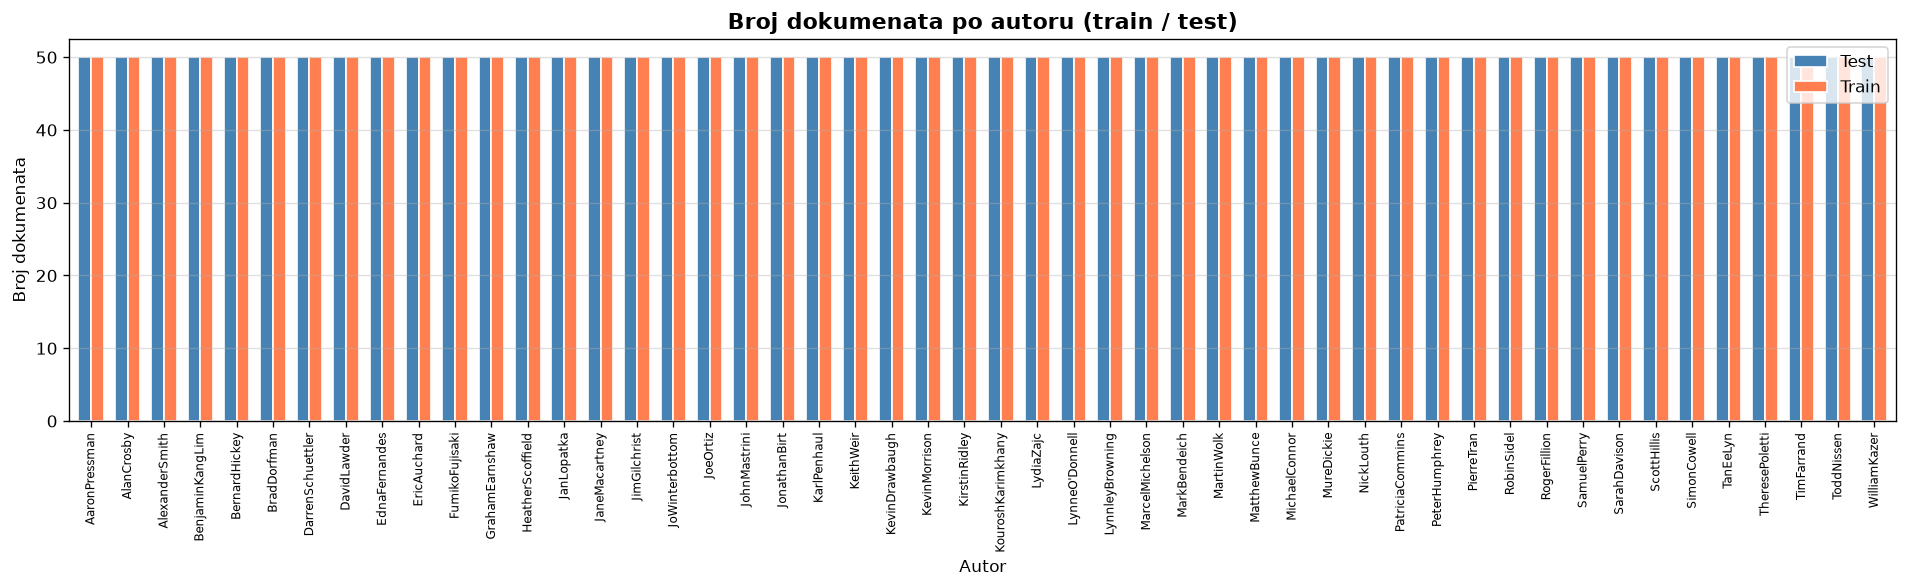

Slika sacuvana: 01_distribucija_autora.png


In [6]:
author_split = df.groupby(['author','split']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(16, 5))
author_split.plot(kind='bar', ax=ax, color=['steelblue','coral'], edgecolor='white', width=0.7)
ax.set_title('Broj dokumenata po autoru (train / test)', fontsize=13, fontweight='bold')
ax.set_xlabel('Autor')
ax.set_ylabel('Broj dokumenata')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
ax.legend(['Test', 'Train'])
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(SLIKE_PATH, '01_distribucija_autora.png'))
plt.show()
print('Slika sacuvana: 01_distribucija_autora.png')

> **Zaključak:** Grafikon potvrđuje da je dataset **potpuno balansiran** — svaki od 50 autora ima identičan broj dokumenata (50 train, 50 test). Ovo je idealna situacija za klasifikaciju jer nema potrebe za balansiranjem klasa (oversampling/undersampling), a sve klase će biti jednako zastupljene tokom treniranja.

### Vizualizacija: distribucija dužine tekstova

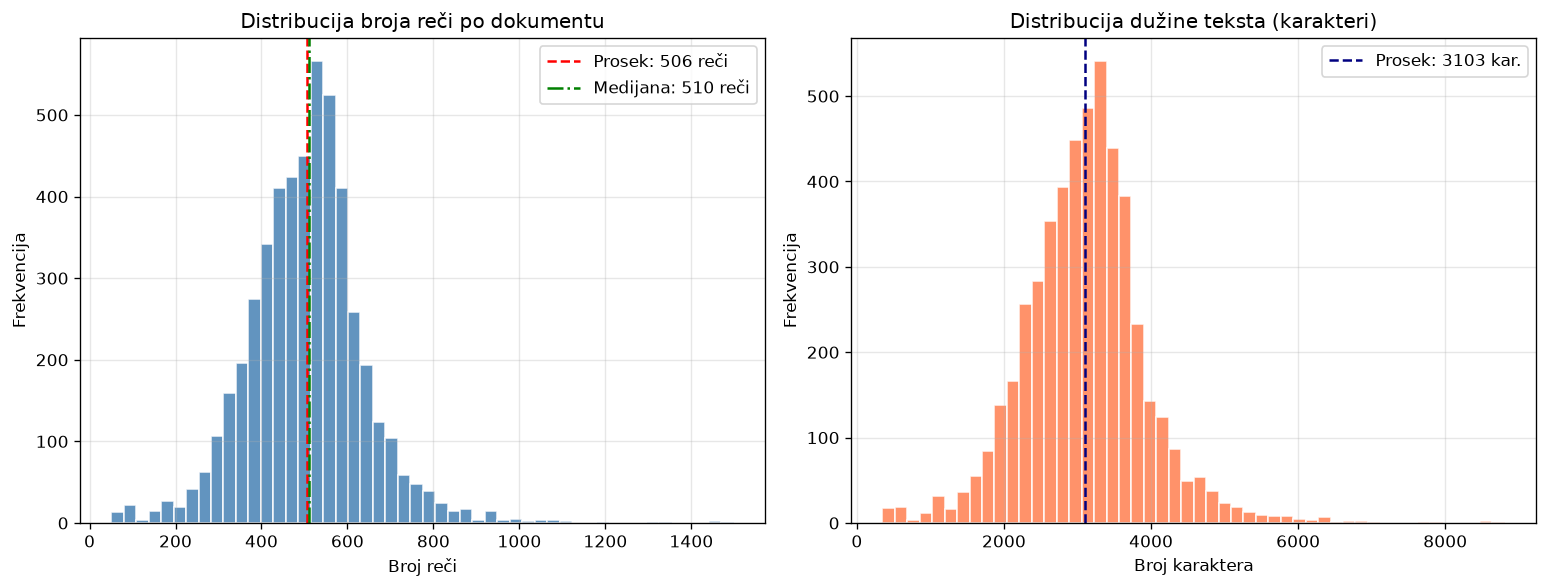

Slika sacuvana: 02_distribucija_duzine.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['word_count'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['word_count'].mean(), color='red', linestyle='--',
                label=f'Prosek: {df["word_count"].mean():.0f} reči')
axes[0].axvline(df['word_count'].median(), color='green', linestyle='-.',
                label=f'Medijana: {df["word_count"].median():.0f} reči')
axes[0].set_title('Distribucija broja reči po dokumentu')
axes[0].set_xlabel('Broj reči')
axes[0].set_ylabel('Frekvencija')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(df['char_count'], bins=50, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(df['char_count'].mean(), color='navy', linestyle='--',
                label=f'Prosek: {df["char_count"].mean():.0f} kar.')
axes[1].set_title('Distribucija dužine teksta (karakteri)')
axes[1].set_xlabel('Broj karaktera')
axes[1].set_ylabel('Frekvencija')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SLIKE_PATH, '02_distribucija_duzine.png'))
plt.show()
print('Slika sacuvana: 02_distribucija_duzine.png')

> **Zaključak:** Distribucija broja reči je bliska normalnoj raspodeli sa blagom pozitivnom asimetrijom — većina tekstova ima između 400 i 600 reči, dok se manji broj veoma dugačkih tekstova (>900 reči) vidi kao desni rep. Prosek (505) i medijana (510) su veoma bliske, što potvrđuje simetričnu raspodelu. Identičan obrazac se vidi i za broj karaktera. Outlieri na levom kraju (tekstovi sa <100 reči) su retki, ali postoje.

### Vizualizacija: boxplot dužine tekstova po autorima

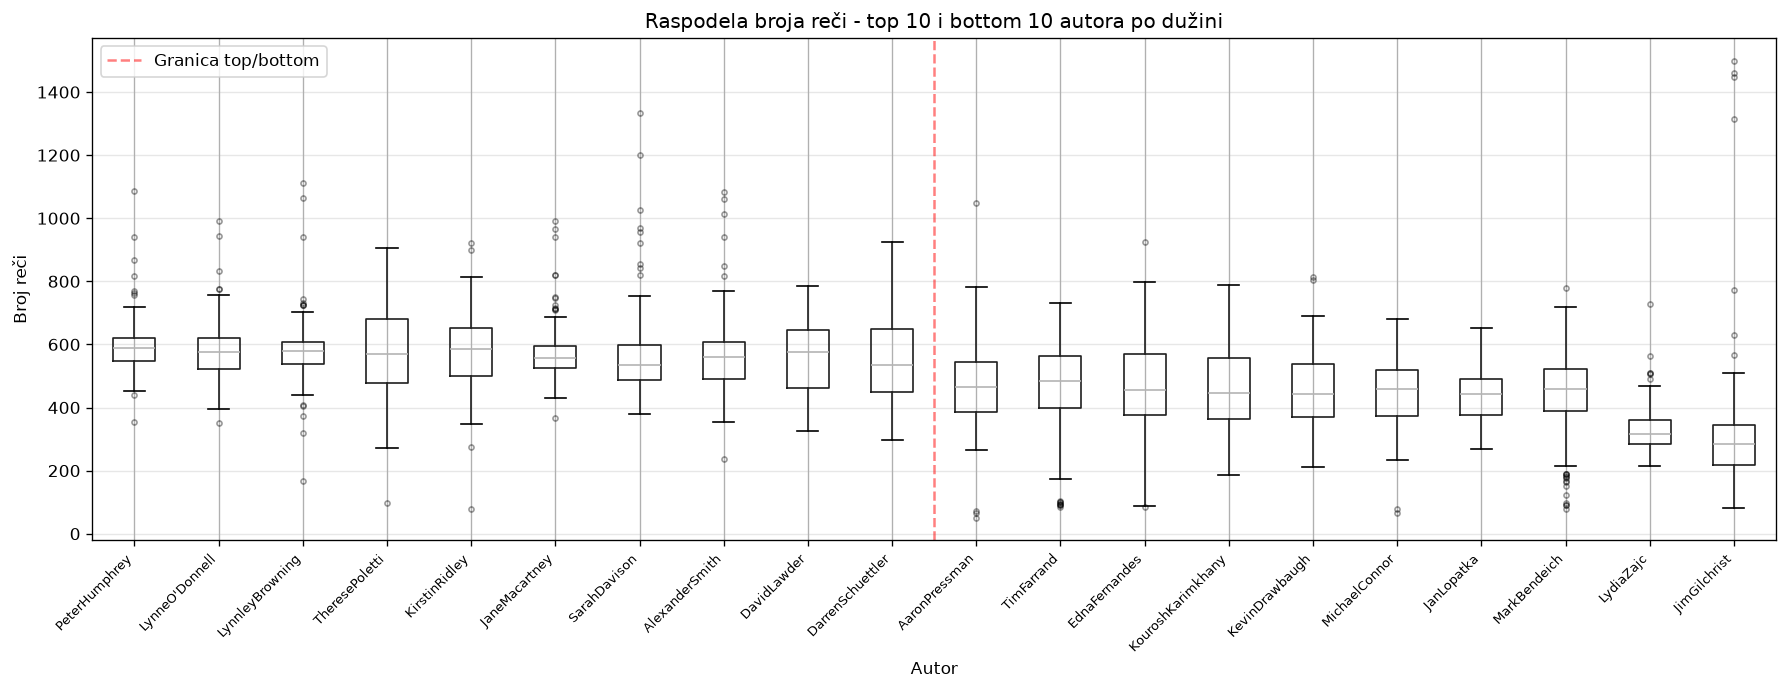

Slika sacuvana: 03_boxplot_duzine.png


In [8]:
avg_wc  = df.groupby('author')['word_count'].mean().sort_values(ascending=False)
top10   = avg_wc.head(10).index.tolist()
bot10   = avg_wc.tail(10).index.tolist()
sel     = df[df['author'].isin(top10 + bot10)].copy()
sel['author'] = pd.Categorical(sel['author'], categories=top10+bot10, ordered=True)
sel = sel.sort_values('author')

fig, ax = plt.subplots(figsize=(15, 6))
sel.boxplot(column='word_count', by='author', ax=ax,
            flierprops=dict(marker='o', markersize=3, alpha=0.4))
ax.set_title('Raspodela broja reči - top 10 i bottom 10 autora po dužini')
plt.suptitle('')
ax.set_xlabel('Autor')
ax.set_ylabel('Broj reči')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.axvline(10.5, color='red', linestyle='--', alpha=0.5, label='Granica top/bottom')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SLIKE_PATH, '03_boxplot_duzine.png'))
plt.show()
print('Slika sacuvana: 03_boxplot_duzine.png')

> **Zaključak:** Boxplot otkriva da autori s dugačkim tekstovima (PeterHumphrey, LynneO'Donnell) imaju i veću varijabilnost u dužini, dok autori kratkih tekstova (JimGilchrist, LydiaZajc) pišu konzistentnije kraće članke. Prisutni su outlieri (tačke van whisker-a) kod većine autora, što odgovara povremenim dužim ili kraćim tekstovima. Razlika između najdužeg (PeterHumphrey, ~598 reči) i najkraćeg (JimGilchrist, ~334 reči) autora iznosi skoro **80%**, što je statistički značajna razlika u stilu pisanja.

### Čuvanje sirovih podataka u CSV

In [9]:
csv_raw = '../data/reuters_raw.csv'
df.to_csv(csv_raw, index=False)
print(f'Sirovi podaci sačuvani: {csv_raw}')
print(f'Dimenzije: {df.shape}')
print(f'Kolone: {list(df.columns)}')

Sirovi podaci sačuvani: ../data/reuters_raw.csv
Dimenzije: (5000, 6)
Kolone: ['author', 'split', 'filename', 'text', 'word_count', 'char_count']


> **Zaključak:** Sirovi podaci su sačuvani u CSV formatu (`reuters_raw.csv`) sa 5000 redova i 6 kolona (uključujući novoizračunate `word_count` i `char_count`). Ovaj fajl služi kao polazna tačka i referenca za poređenje sa preprocesiranim podacima.